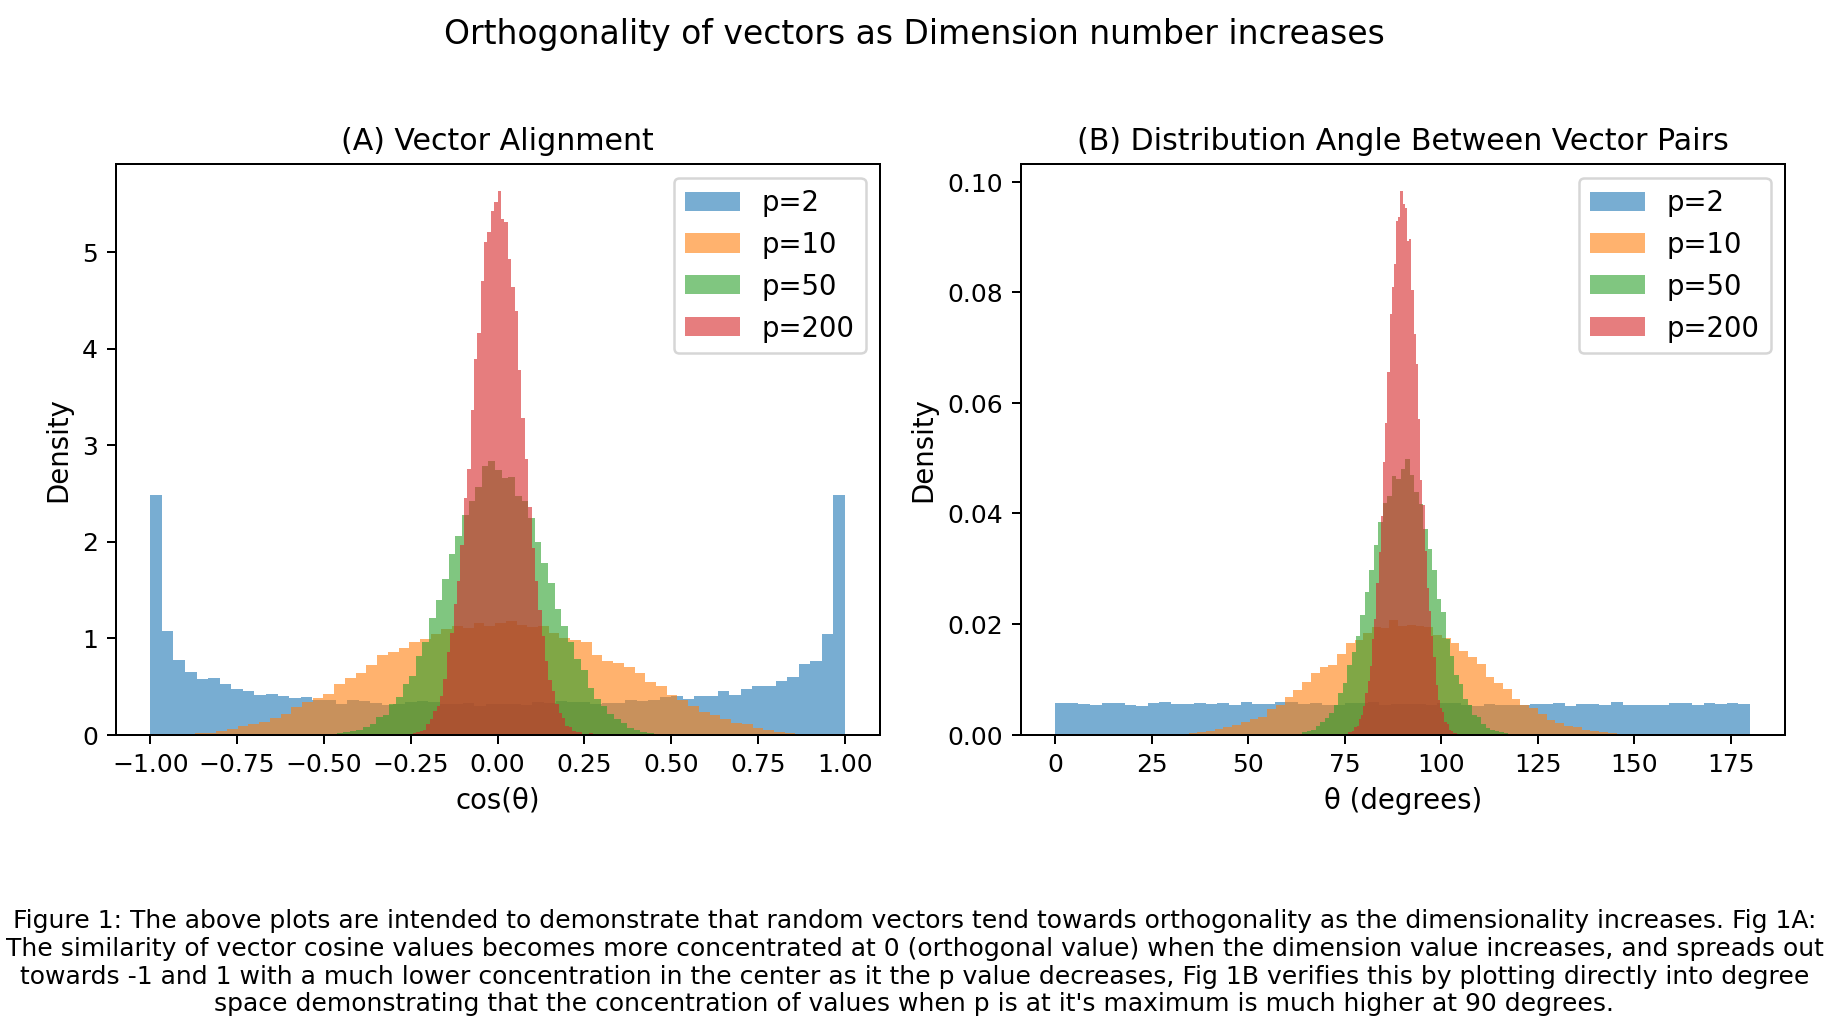

In [49]:
# Dependencies
import numpy as np
import matplotlib.pyplot as plt

# Inputs
SEED = 7
FIGSIZE = (10, 4.5)
DPI = 180
FIG_TITLE = "Orthogonality of vectors as Dimension number increases"

# dimensions
P_LIST = [2, 10, 50, 200]

# number of random vector pairs per dimension
N_PAIRS = 50000

# data distribution
DIST = "normal"  # "normal" or "uniform01"

# histogram format
BINS = 60
ALPHA = 0.6

# Functions
rng = np.random.default_rng(SEED)

def sample_vectors(n, p):
    if DIST == "normal":
        return rng.normal(0, 1, size=(n, p))
    if DIST == "uniform01":
        return rng.random((n, p))
    raise ValueError("DIST must be 'normal' or 'uniform01'")

def cosine_and_angle(p, n_pairs):
    A = sample_vectors(n_pairs, p)
    B = sample_vectors(n_pairs, p)

    dot = np.einsum("ij,ij->i", A, B)
    normA = np.linalg.norm(A, axis=1)
    normB = np.linalg.norm(B, axis=1)

    cos = dot / (normA * normB)
    cos = np.clip(cos, -1, 1)

    theta = np.degrees(np.arccos(cos))
    return cos, theta


# Data distributions
cos_data = {}
theta_data = {}

for p in P_LIST:
    cos, theta = cosine_and_angle(p, N_PAIRS)
    cos_data[p] = cos
    theta_data[p] = theta

# Figures
fig, axs = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI)
fig.suptitle(FIG_TITLE, y=1.02)

# Panel A: cosine similarity
ax = axs[0]
for p in P_LIST:
    ax.hist(cos_data[p], bins=BINS, density=True, alpha=ALPHA, label=f"p={p}")

ax.set_title("(A) Vector Alignment")
ax.set_xlabel("cos(θ)")
ax.set_ylabel("Density")
ax.legend(frameon=True)

# Panel B: angle
ax = axs[1]
for p in P_LIST:
    ax.hist(theta_data[p], bins=BINS, density=True, alpha=ALPHA, label=f"p={p}")

ax.set_title("(B) Distribution Angle Between Vector Pairs")
ax.set_xlabel("θ (degrees)")
ax.set_ylabel("Density")
ax.legend(frameon=True)

caption = (
    "Figure 1: The above plots are intended to demonstrate that random vectors tend towards orthogonality as the dimensionality increases. Fig 1A: The similarity of vector cosine values becomes more concentrated at 0 (orthogonal value) when the dimension value increases, and spreads out towards -1 and 1 with a much lower concentration in the center as it the p value decreases, Fig 1B verifies this by plotting directly into degree space demonstrating that the concentration of values when p is at it's maximum is much higher at 90 degrees.")

fig.text(
    0.5, -0.08, caption,   # x centered, y below figure
    ha="center",
    va="top",
    fontsize=10,
    wrap=True
)

plt.tight_layout()
plt.savefig("ccstuhl_cod.png", bbox_inches="tight", dpi=300)
plt.show()

